In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as curve_fit

In [5]:
path = Path.cwd().joinpath("readings.csv")
csv = pd.read_csv(path)

print(csv.head())

   Voltage  Resistance   Current  Reading 1  Reading 2
0     26.7        47.0  0.568085        132        188
1     26.7        41.3  0.646489        138        219
2     26.7        31.3  0.853035        199        270
3     26.7        22.5  1.186667        291        385
4     26.7        18.8  1.420213        360        411


Average reading difference:  -35.09090909090909


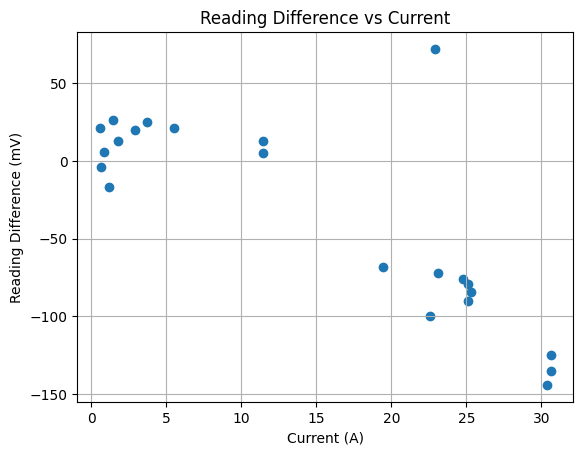

In [6]:
reading_1_offset = -20
reading_2_offset = 57

csv["Adjusted Reading 1"] = csv["Reading 1"] - reading_1_offset
csv["Adjusted Reading 2"] = csv["Reading 2"] - reading_2_offset
csv["Reading Difference"] = csv["Adjusted Reading 1"] - csv["Adjusted Reading 2"]

print("Average reading difference: ", csv["Reading Difference"].mean())

plt.scatter(csv['Current'], csv["Reading Difference"])
plt.xlabel("Current (A)")
plt.ylabel("Reading Difference (mV)")
plt.title("Reading Difference vs Current")
plt.grid()

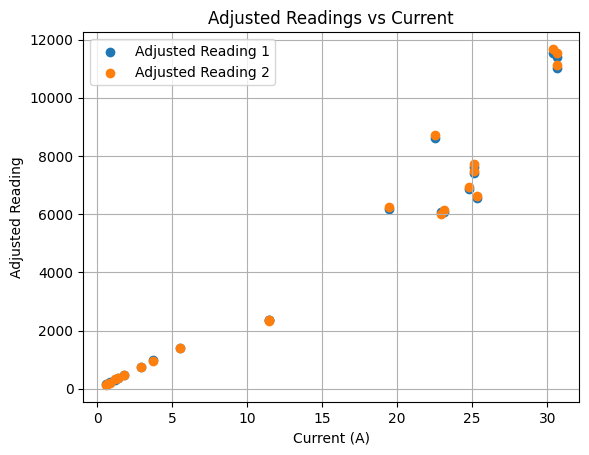

In [38]:
# Plotting 2 seperate lines for the adjusted readings
plt.figure()
plt.scatter(csv['Current'], csv["Adjusted Reading 1"], label="Adjusted Reading 1")
plt.scatter(csv['Current'], csv["Adjusted Reading 2"], label="Adjusted Reading 2")
plt.xlabel("Current (A)")
plt.ylabel("Adjusted Reading")
plt.title("Adjusted Readings vs Current")
plt.legend()
plt.grid()
plt.show()

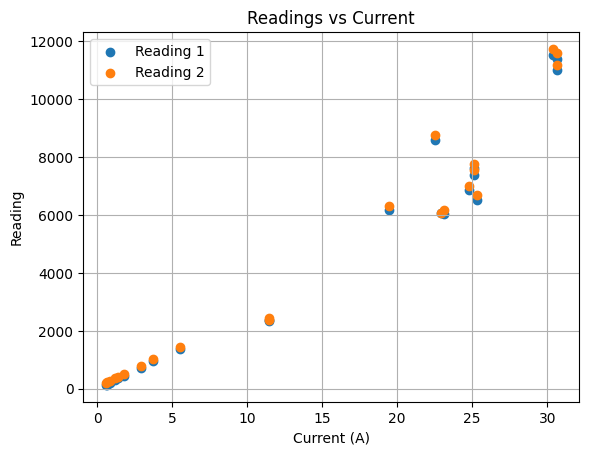

In [39]:
# Plotting 2 seperate lines for the adjusted readings
plt.figure()
plt.scatter(csv['Current'], csv["Reading 1"], label="Reading 1")
plt.scatter(csv['Current'], csv["Reading 2"], label="Reading 2")
plt.xlabel("Current (A)")
plt.ylabel("Reading")
plt.title("Readings vs Current")
plt.legend()
plt.grid()
plt.show()

In [26]:
csv['Consolidated Reading'] = (csv["Adjusted Reading 1"] + csv["Adjusted Reading 2"]) / 2

curve_fit_func = lambda x, a, b, c: a * x**2 + b * x + c
params, _ = curve_fit.curve_fit(curve_fit_func, csv['Current'], csv['Consolidated Reading'])
a, b, c = params
print(f"Fitted curve parameters: a={a}, b={b}, c={c}")
print(f"Fitted curve: y = {a:.8f} * x**2 + {b:.8f}*x + {c:.8f}")
print(f"Zero current reading: {c*0.0001875:.4f} V")

#R-squared value
residuals = csv['Consolidated Reading'] - curve_fit_func(csv['Current'], *params)
residual_sum_squares = np.sum(residuals**2)
total_sum_squares = np.sum((csv['Consolidated Reading'] - np.mean(csv['Consolidated Reading']))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")


Fitted curve parameters: a=8.710689024823978, b=83.83784206428071, c=287.2389662966983
Fitted curve: y = 8.71068902 * x**2 + 83.83784206*x + 287.23896630
Zero current reading: 0.0539 V
R-squared value: 0.9707


In [81]:
csv['Consolidated Reading'] = (csv["Adjusted Reading 1"] + csv["Adjusted Reading 2"]) / 2

curve_fit_func_zeroed = lambda x, a, b: a * x**2 + b * x
params, _ = curve_fit.curve_fit(curve_fit_func_zeroed, csv['Current'], csv['Consolidated Reading'])
a, b = params
print(f"Fitted curve parameters: a={a}, b={b}")
print(f"Fitted curve: y = {a:.8f} * x**2 + {b:.8f}*x")
print(f"Zero current reading: {0:.4f} V")

#R-squared value
residuals = csv['Consolidated Reading'] - curve_fit_func_zeroed(csv['Current'], *params)
residual_sum_squares = np.sum(residuals**2)
total_sum_squares = np.sum((csv['Consolidated Reading'] - np.mean(csv['Consolidated Reading']))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")


Fitted curve parameters: a=7.591098087753353, b=124.8084854869866
Fitted curve: y = 7.59109809 * x**2 + 124.80848549*x
Zero current reading: 0.0000 V
R-squared value: 0.9693


In [82]:
csv['Consolidated Reading'] = (csv["Adjusted Reading 1"] + csv["Adjusted Reading 2"]) / 2

curve_fit_func_linear = lambda x, a, b: a * x + b
params, _ = curve_fit.curve_fit(curve_fit_func_linear, csv['Current'], csv['Consolidated Reading'])
a, b = params
print(f"Fitted curve parameters: a={a}, b={b}")
print(f"Fitted curve: y = {a:.8f} * x + {b:.8f}")
print(f"Zero current reading: {b:.4f} V")

#R-squared value
residuals = csv['Consolidated Reading'] - curve_fit_func_linear(csv['Current'], *params)
residual_sum_squares = np.sum(residuals**2)
total_sum_squares = np.sum((csv['Consolidated Reading'] - np.mean(csv['Consolidated Reading']))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")


Fitted curve parameters: a=338.08555935953666, b=-426.07353917533106
Fitted curve: y = 338.08555936 * x + -426.07353918
Zero current reading: -426.0735 V
R-squared value: 0.9446


In [84]:
csv['Consolidated Reading'] = (csv["Adjusted Reading 1"] + csv["Adjusted Reading 2"]) / 2

curve_fit_func_sigmoid = lambda x, L, k, x0: L / (1 + np.exp(-k * (x - x0)))
p0 = [30000, 0.1, 50]

params, _ = curve_fit.curve_fit(curve_fit_func_sigmoid, csv['Current'], csv['Consolidated Reading'], p0=p0)
L, k, x0 = params
print(f"Fitted curve parameters: L={L}, k={k}, x0={x0}")
print(f"Fitted curve: y = {L:.8f} / (1 + np.exp(-{k:.8f} * (x - {x0:.8f})))")
print(f"Zero current reading: {0:.4f} V")

#R-squared value
residuals = csv['Consolidated Reading'] - curve_fit_func_sigmoid(csv['Current'], *params)
residual_sum_squares = np.sum(residuals**2)
total_sum_squares = np.sum((csv['Consolidated Reading'] - np.mean(csv['Consolidated Reading']))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")


Fitted curve parameters: L=20652.4120267655, k=0.12023528688829592, x0=29.206230040499047
Fitted curve: y = 20652.41202677 / (1 + np.exp(-0.12023529 * (x - 29.20623004)))
Zero current reading: 0.0000 V
R-squared value: 0.9667


In [85]:
csv['Consolidated Reading'] = (csv["Adjusted Reading 1"] + csv["Adjusted Reading 2"]) / 2

curve_fit_func_ended = lambda x, a, b: a * x**2 + b * x
params, _ = curve_fit.curve_fit(curve_fit_func_ended, np.append(csv['Current'], 100), np.append(csv['Consolidated Reading'], 5 / 0.0001875))
a, b = params
print(f"Fitted curve parameters: a={a}, b={b}")
print(f"Fitted curve: y = {a:.8f} * x**2 + {b:.8f}*x")
print(f"Zero current reading: {0:.4f} V")

#R-squared value
residuals = np.append(csv['Consolidated Reading'] - curve_fit_func_ended(csv['Current'], *params), 5 / 0.0001875 - curve_fit_func_ended(100, *params))
residual_sum_squares = np.sum(residuals**2)
total_sum_squares = np.sum((np.append(csv['Consolidated Reading'], 5 / 0.0001875) - np.mean(np.append(csv['Consolidated Reading'], 5 / 0.0001875)))**2)
r_squared = 1 - (residual_sum_squares / total_sum_squares)
print(f"R-squared value: {r_squared:.4f}")


Fitted curve parameters: a=-0.6572687402320041, b=334.34596195700385
Fitted curve: y = -0.65726874 * x**2 + 334.34596196*x
Zero current reading: 0.0000 V
R-squared value: 0.9722


In [86]:
fitted_squared = lambda x: 8.71068902 * x**2 + 83.83784206*x + 287.23896630
fitted_squared_zeroed = lambda x: 7.59109809 * x**2 + 124.80848549*x
fitted_linear = lambda x: 338.08555936 * x + -426.07353918
fitted_sigmoid = lambda x: 20652.41202677 / (1 + np.exp(-0.12023529 * (x - 29.20623004)))
fitted_ended = lambda x: -0.65726874 * x**2 + 334.34596196*x
fitted_ideal_linear = lambda x: 5 / 0.0001875 / 100 * x

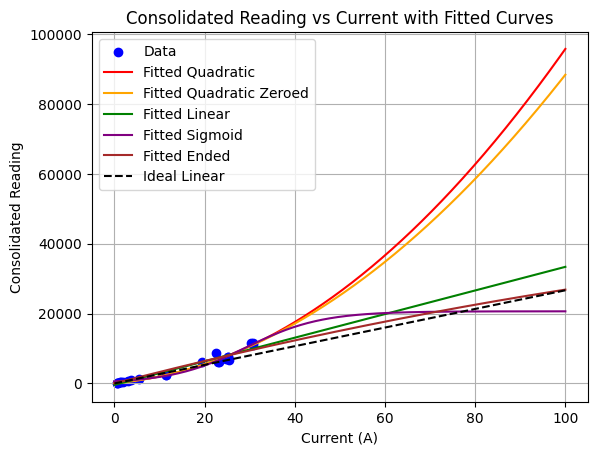

In [87]:
plt.scatter(csv['Current'], csv['Consolidated Reading'], label="Data", color='blue')

x_values = np.linspace(0, 100, 500)
plt.plot(x_values, fitted_squared(x_values), label="Fitted Quadratic", color='red')
plt.plot(x_values, fitted_squared_zeroed(x_values), label="Fitted Quadratic Zeroed", color='orange')
plt.plot(x_values, fitted_linear(x_values), label="Fitted Linear", color='green')
plt.plot(x_values, fitted_sigmoid(x_values), label="Fitted Sigmoid", color='purple')
plt.plot(x_values, fitted_ended(x_values), label="Fitted Ended", color='brown')
plt.plot(x_values, fitted_ideal_linear(x_values), label="Ideal Linear", color='black', linestyle='dashed')
plt.xlabel("Current (A)")
plt.ylabel("Consolidated Reading")
plt.title("Consolidated Reading vs Current with Fitted Curves")
plt.legend()
plt.grid()

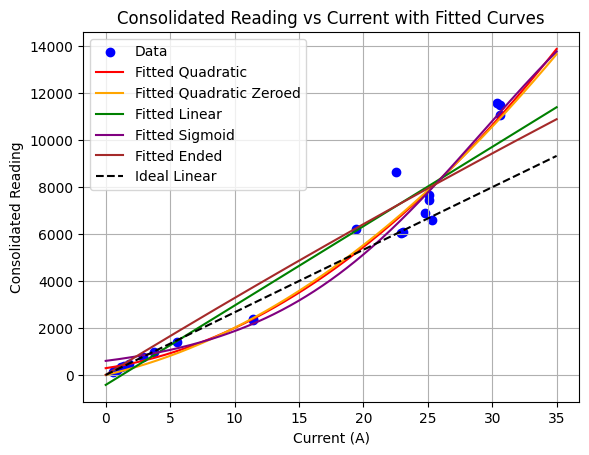

In [88]:
plt.scatter(csv['Current'], csv['Consolidated Reading'], label="Data", color='blue')

x_values = np.linspace(0, 35, 500)
plt.plot(x_values, fitted_squared(x_values), label="Fitted Quadratic", color='red')
plt.plot(x_values, fitted_squared_zeroed(x_values), label="Fitted Quadratic Zeroed", color='orange')
plt.plot(x_values, fitted_linear(x_values), label="Fitted Linear", color='green')
plt.plot(x_values, fitted_sigmoid(x_values), label="Fitted Sigmoid", color='purple')
plt.plot(x_values, fitted_ended(x_values), label="Fitted Ended", color='brown')
plt.plot(x_values, fitted_ideal_linear(x_values), label="Ideal Linear", color='black', linestyle='dashed')
plt.xlabel("Current (A)")
plt.ylabel("Consolidated Reading")
plt.title("Consolidated Reading vs Current with Fitted Curves")
plt.legend()
plt.grid()